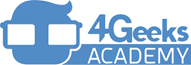

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 20</b>: Boosting</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. Boosting](#boosting)
- [2. Algoritmo](#algoritmo)
  - [2.1. Adaptive Boosting (AdaBoost)](#ada)
  - [2.2. Gradient Boosting](#gradient)
  - [2.3. Extreme Gradient Boosting (XGBoost)](#xgboost)
  - [2.4. Light Gradient Boosting Machine (LightGBM)](#light)
- [3. Hiperparámetros](#hiperparametros)
- [4. Boosting vs Random forest](#comparacion)
- [5. Ejemplo práctico](#ejemplo)
- [6. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

from sklearn.metrics import mean_squared_error, r2_score

from pickle import dump

import warnings
warnings.filterwarnings('ignore')

In [2]:
pip install xgboost

In [3]:
!pip install lightgbm

## 1. Boosting <a name="boosting"></a>

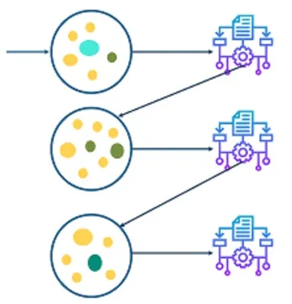

**Boosting** es una técnica de ensemble que se utiliza para mejorar el rendimiento de los modelos.

A diferencia del bagging, que crea modelos independientes en paralelo, el boosting construye modelos secuenciales donde cada nuevo modelo intenta corregir los errores de los modelos anteriores.

Existin diversas implementaciones, todas con su versión clasificacor y regresor. Algunas basadas sólo en árboles y otras permiten ensamblar otros tipos de modelos.

#### Ventajas

- Mejora de la Precisión: Boosting puede mejorar significativamente la precisión de los modelos débiles combinándolos en un modelo fuerte.

- Flexibilidad: Puede ser aplicado a una amplia variedad de modelos base, no solo árboles de decisión.

- Reducción del Sesgo y Varianza: El boosting reduce tanto el sesgo como la varianza, lo que resulta en un modelo más robusto y preciso.

### Desventajas

- Riesgo de Sobreajuste: Si no se controla adecuadamente, el boosting puede sobreajustar los datos de entrenamiento, especialmente si los modelos son muy complejos.

- Requisitos Computacionales: El entrenamiento puede ser computacionalmente costoso, especialmente para conjuntos de datos grandes.

- Interpretabilidad: Los modelos de boosting pueden ser difíciles de interpretar debido a la complejidad y la combinación de múltiples modelos.

## 2. Algoritmo <a name="algoritmo"></a>

La estructura de un algoritmo de boosting sigue un proceso caracterizado con los siguientes pasos:

**1. Inicialización**. Primero, se asigna un peso inicial a cada instancia (fila) en el conjunto de entrenamiento. Por lo general, estos pesos son iguales para todas las instancias al inicio.

**2. Entrenamiento del primer modelo**. Se entrena un modelo con los datos de entrenamiento. Este modelo hará algunas predicciones correctas y algunas incorrectas.

**3. Cálculo de errores**. se calcula el error del modelo anterior en función de los pesos anteriores.

  Las instancias mal clasificadas por este modelo recibirán un mayor peso, de manera que se destacarán en el siguiente paso.

**4. Entrenamiento del segundo modelo**. Se entrena un nuevo modelo, pero ahora se enfoca más en las instancias con mayor peso (las que el modelo anterior clasificó erróneamente).

**5. Iteración**. Se repiten los pasos 3 y 4 para un número predefinido de veces, o hasta que se alcance un límite de error aceptable.

Cada nuevo modelo se concentra en corregir los errores del modelo anterior.

**6. Combinación de los modelos**. los modelos se combinan a través de una suma ponderada de sus predicciones.

Los modelos que tienen un mejor rendimiento (es decir, cometen menos errores en sus predicciones) suelen tener mayor peso en la suma.

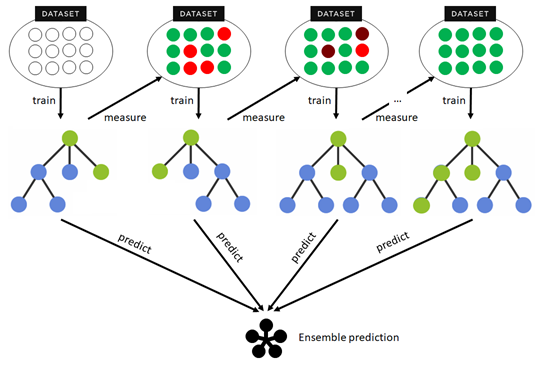

### 2.1. Adaptive Boosting (AdaBoost) <a name="ada"></a>

Fue uno de los primeros algoritmos de boosting y ajusta iterativamente los pesos de las observaciones en el conjunto de datos de entrenamiento.

A cada instancia de los datos se le asigna un peso. Después de cada ronda de entrenamiento, las instancias mal clasificadas se les da más peso, y las instancias bien clasificadas se les da menos peso.

Permite usal diversos modelos no solo árboles.

### 2.2. Gradient Boosting <a name="gradient"></a>

En lugar de ajustar los pesos de las instancias, el gradient boosting ajusta los errores residuales.

Cada modelo se entrena para corregir los errores residuales de la suma de los modelos anteriores.

Utiliza métodos de optimización de gradiente para minimizar la función de pérdida.

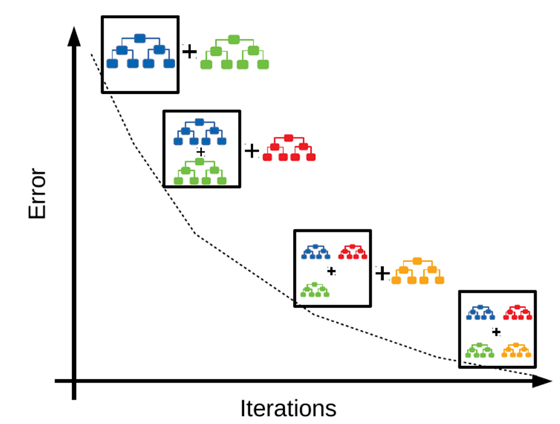

### 2.3. Extreme Gradient Boosting (XGBoost) <a name="xgboost"></a>

Una implementación optimizada de gradient boosting que es más eficiente en términos de velocidad y uso de memoria.

Utiliza una estrategia de crecimiento Depth-wise o Level-wise, donde todos los nodos de un nivel se expanden antes de pasar al siguiente nivel.

También incluye optimizaciones como la paralelización del proceso de creacion del árbol y la poda de árboles para mejorar la eficiencia.

Incluye regularización para evitar el sobreajuste y es conocido por su rendimiento en competiciones de machine learning.

### 2.4. Light Gradient Boosting Machine (LightGBM) <a name="light"></a>

Utiliza una técnica llamada Leaf-wise Tree Growth en lugar de Depth-wise. Esto significa que los árboles crecen seleccionando primero las hojas con mayor pérdida, lo que puede generar árboles más profundos y precisos.

Implementa técnicas de histogram binning para reducir el costo computacional y la memoria utilizada.

Es especialmente eficiente para grandes conjuntos de datos y puede manejar millones de registros con rapidez.

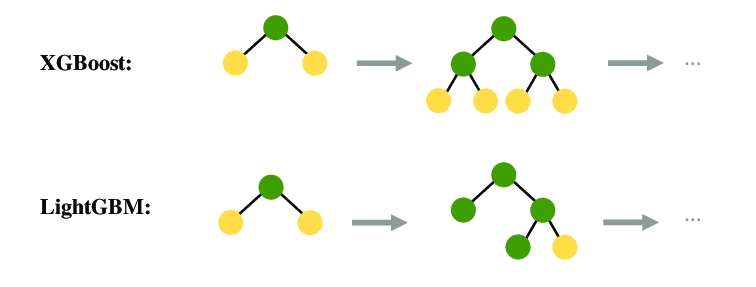

## 3. Hiperparámetros <a name="hiperparametros"></a>

Los hiperparámetros dependen de la implementación a utilizar pero algunos de los más importantes son:

**n_estimators**: define el número modelos a usar.

**estimator**: indica que tipo de modelo usar.

**learning_rate**: La tasa a la cual se acepta el modelo en cada etapa de boosting. Una tasa de aprendizaje más elevada puede llevar a un modelo más complejo, mientras que una tasa más baja requerirá más árboles para obtener el mismo nivel de complejidad.

**loss (u objective)**: La función de pérdida a optimizar (cantidad de errores de clasificación o diferencia con la realidad en regresión).

**subsample**: La fracción de instancias a utilizar para entrenar los modelos. Si es menor que 1.0, entonces cada árbol se entrena con una fracción aleatoria del total de las instancias del dataset de entrenamiento.

**max_depth**: la profundidad máxima de los árboles. Esto es esencialmente cuántas divisiones puede hacer el árbol antes de hacer una predicción.

**min_samples_split**: El número mínimo de muestras necesarias para dividir un nodo en cada árbol. Si se establece un valor alto, evita que el modelo aprenda relaciones demasiado específicas y, por tanto, ayuda a prevenir el sobreajuste.

**min_samples_leaf**: El número mínimo de muestras que se deben tener en un nodo hoja en cada árbol.

**max_features**: El número máximo de características a considerar al buscar la mejor división dentro de cada árbol. Por ejemplo, si tenemos 10 características, podemos elegir que cada árbol considere solo un subconjunto de ellas al decidir dónde dividir.

## 4. Boosting vs Random forest <a name="comparacion"></a>


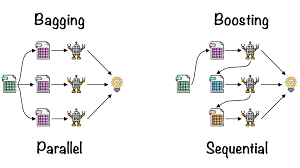

|                           |                                                     Boosting                                                     |                                             Random forest                                             |
|:-------------------------:|:----------------------------------------------------------------------------------------------------------------:|:-----------------------------------------------------------------------------------------------------:|
| Estrategia<br>de ensamble    | Secuencial, cada uno intenta corregir los errores del modelo anterior.          | Paralelo, modelo independientes, cada uno con una muestra aleatoria de los datos       |
| Capacidad de<br>modelado     | Puede capturar relaciones complejas y no lineales en los datos.                                                  | Menor capacidad de capturar relaciones complejas y no lineales.                         |
| Prevención de<br>sobreajuste | Más propenso al sobreajuste.                  | Generalmente menos propenso al sobreajuste.                                                           |
| Rendimiento   | Mayor rendimiento en términos de precisión, pero puede ser más sensible a los hiperparámetros. | Menor rendimiento de precisión, pero es más robusto a las variaciones de hiperparámetros. |
| Tiempo de<br>entrenamiento   | Más lento (uno detrás de otro)   | Más rápido (paralelo)        |
| Datos   | Mejor con grandes volumenes   | Para pocos o muchos datos        |
| Distribuciones   | Puede manejar distribuciones no usuales   | Es robusto a las distribuciones usuales        |
| Outliers   | Muy sensible   | Robusto a valores atípicos        |

## 5. Ejemplo práctico <a name="ejemplo"></a>

#### Boosting para clasificación

Para ejemplificar la implementación de un algoritmo de boosting para clasificación utilizaremos el mismo conjunto de datos que para el caso de los árboles de decisión y del random forest.

## Paso 1. Lectura del conjunto de datos procesado

## Paso 2. Selección de variables

In [4]:
X, y = load_iris(return_X_y = True, as_frame = True)

In [5]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [6]:
X_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


Siendo la clase `0` una `iris setosa`, la `1` una `iris versicolor` y la `2` una `iris virginica`.

In [7]:
y.unique()

array([0, 1, 2])

## Paso 3. Modelado

In [8]:
# modelos
# base_estimator  por defecto es arbol de calsificacion
# base_estimator sire para elegir el modelo base
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state = 42, use_label_encoder=False, eval_metric='mlogloss')
lgb = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state = 42)

# entrenamiento
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 91
[LightGBM] [Info] Number of data points in the train set: 120, number of used features: 4
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.073920
[LightGBM] [Info] Start training from score -1.123930
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

LGBMClassifier(random_state=42)

In [9]:
# predicción
ada_y_pred_test = ada.predict(X_test)
gb_y_pred_test = gb.predict(X_test)
xgb_y_pred_test = xgb.predict(X_test)
lgb_y_pred_test = lgb.predict(X_test)

ada_y_pred_train = ada.predict(X_train)
gb_y_pred_train = gb.predict(X_train)
xgb_y_pred_train = xgb.predict(X_train)
lgb_y_pred_train = lgb.predict(X_train)

In [10]:
# metricas
ada_accuracy_test = accuracy_score(y_test, ada_y_pred_test)
ada_accuracy_train = accuracy_score(y_train, ada_y_pred_train)

gb_accuracy_test = accuracy_score(y_test, gb_y_pred_test)
gb_accuracy_train = accuracy_score(y_train, gb_y_pred_train)

xgb_accuracy_test = accuracy_score(y_test, xgb_y_pred_test)
xgb_accuracy_train = accuracy_score(y_train, xgb_y_pred_train)

lgb_accuracy_test = accuracy_score(y_test, lgb_y_pred_test)
lgb_accuracy_train = accuracy_score(y_train, lgb_y_pred_train)

print('AdaBoost')
print("Accuracy Test: ", ada_accuracy_test)
print("Accuracy Train: ", ada_accuracy_train)

print('Gradient Boosting')
print("Accuracy Test: ", gb_accuracy_test)
print("Accuracy Train: ", gb_accuracy_train)

print('XGBoost')
print("Accuracy Test: ", xgb_accuracy_test)
print("Accuracy Train: ", xgb_accuracy_train)

print('LightGBM')
print("Accuracy Test: ", lgb_accuracy_test)
print("Accuracy Train: ", lgb_accuracy_train)


AdaBoost
Accuracy Test:  1.0
Accuracy Train:  0.9583333333333334
Gradient Boosting
Accuracy Test:  1.0
Accuracy Train:  1.0
XGBoost
Accuracy Test:  1.0
Accuracy Train:  1.0
LightGBM
Accuracy Test:  1.0
Accuracy Train:  1.0


#### Boosting para regresión

Para ejemplificar la implementación de un algoritmo de boosting para regresión utilizaremos el mismo conjunto de datos que para el caso de los árboles de decisión y del random forest.

## Paso 1. Lectura del conjunto de datos procesado

In [11]:
# conexion drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/18_arboles/data/clean_petrol_consumption_train.csv'
train_data = pd.read_csv(archivo)

train_data.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,8.0,4447,8577,0.529,464
1,7.5,4870,2351,0.529,414
2,8.0,5319,11868,0.451,344
3,7.0,4345,3905,0.672,968
4,7.5,3357,4121,0.547,628


In [14]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/18_arboles/data/clean_petrol_consumption_test.csv'
test_data = pd.read_csv(archivo)

test_data.head()

,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,7.5,3846,9061,0.579,631
1,7.0,4449,4639,0.626,587
2,8.0,3448,5399,0.548,577
3,7.0,3745,2611,0.508,591
4,8.5,4574,2619,0.551,460


## Paso 2. Selección de variables

In [15]:
X_train = train_data.drop(["Petrol_Consumption"], axis = 1)
y_train = train_data["Petrol_Consumption"]

X_test = test_data.drop(["Petrol_Consumption"], axis = 1)
y_test = test_data["Petrol_Consumption"]

## Paso 3. Modelado

In [16]:
# modelos
ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state = 42)
lgb = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state = 42)

# entrenamiento
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgb.fit(X_train, y_train)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 38, number of used features: 0
[LightGBM] [Info] Start training from score 578.789474
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the sp

LGBMRegressor(random_state=42)

In [17]:
ada_y_pred_test = ada.predict(X_test)
gb_y_pred_test = gb.predict(X_test)
xgb_y_pred_test = xgb.predict(X_test)
lgb_y_pred_test = lgb.predict(X_test)

ada_y_pred_train = ada.predict(X_train)
gb_y_pred_train = gb.predict(X_train)
xgb_y_pred_train = xgb.predict(X_train)
lgb_y_pred_train = lgb.predict(X_train)

In [18]:
# metricas
ada_mse_test = mean_squared_error(y_test, ada_y_pred_test)
gb_mse_test = mean_squared_error(y_test, gb_y_pred_test)
xgb_mse_test = mean_squared_error(y_test, xgb_y_pred_test)
lgb_mse_test = mean_squared_error(y_test, lgb_y_pred_test)

ada_rmse_test = np.sqrt(ada_mse_test)
gb_rmse_test = np.sqrt(gb_mse_test)
xgb_rmse_test = np.sqrt(xgb_mse_test)
lgb_rmse_test = np.sqrt(lgb_mse_test)

print('AdaBoost')
print("MSE Test: ", ada_mse_test)
print("RMSE Test: ", ada_rmse_test)

print('Gradient Boosting')
print("MSE Test: ", gb_mse_test)
print("RMSE Test: ", gb_rmse_test)

print('XGBoost')
print("MSE Test: ", xgb_mse_test)
print("RMSE Test: ", xgb_rmse_test)

print('LightGBM')
print("MSE Test: ", lgb_mse_test)
print("RMSE Test: ", lgb_rmse_test)

AdaBoost
MSE Test:  14011.996545817648
RMSE Test:  118.37227946532772
Gradient Boosting
MSE Test:  12375.228186461583
RMSE Test:  111.24400292358048
XGBoost
MSE Test:  14457.8798828125
RMSE Test:  120.24092432617316
LightGBM
MSE Test:  6802.775900277009
RMSE Test:  82.47894216269393


## 6. Links de interés <a name="links"></a>

- [Ensamble con SkLearn](https://scikit-learn.org/stable/api/sklearn.ensemble.html)
- [Understanding Gradient Boosting]( https://medium.com/@hemashreekilari9/understanding-gradient-boosting-632939b98764)
- [Understand different types of Boosting Algorithms](https://iq.opengenus.org/types-of-boosting-algorithms/)